In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [13]:
def load_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Image not found at the specified path!")
    img = img / 255.0
    return img

def simulate_degradation(image, kernel_size=15, noise_std_dev=0.1):
    kernel_motion_blur = np.zeros((kernel_size, kernel_size))
    kernel_motion_blur[int((kernel_size-1)/2), :] = np.ones(kernel_size)
    kernel_motion_blur = kernel_motion_blur / kernel_size
    
    blurred_image = cv2.filter2D(image, -1, kernel_motion_blur)
    
    noise = np.random.normal(loc=0.0, scale=noise_std_dev, size=image.shape)
    degraded_image = blurred_image + noise
    degraded_image = np.clip(degraded_image, 0, 1)
    
    return degraded_image, kernel_motion_blur

def inverse_filter_restore(degraded_img, kernel):
    degraded_fft = np.fft.fft2(degraded_img)
    kernel_fft = np.fft.fft2(kernel, s=degraded_img.shape)
    epsilon = 1e-10
    restored_fft = degraded_fft / (kernel_fft + epsilon)
    restored_image = np.fft.ifft2(restored_fft)
    return np.real(restored_image)

def wiener_filter_restore(degraded_img, kernel, K=0.01):
    degraded_fft = np.fft.fft2(degraded_img)
    kernel_fft = np.fft.fft2(kernel, s=degraded_img.shape)
    
    kernel_fft_conj = np.conj(kernel_fft)
    kernel_power_spectrum = np.abs(kernel_fft)**2
    
    wiener_filter = kernel_fft_conj / (kernel_power_spectrum + K)
    
    restored_fft = degraded_fft * wiener_filter
    restored_image = np.fft.ifft2(restored_fft)
    
    return np.real(restored_image)

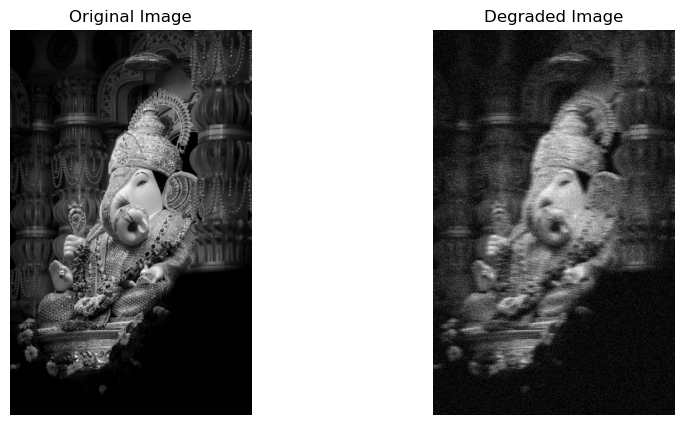

In [15]:
try:
    original_image = load_image("C:/Users/dhira/Downloads/Bappa.jpg")
    degraded_image, blur_kernel = simulate_degradation(original_image, kernel_size=15, noise_std_dev=0.1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original_image, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(degraded_image, cmap='gray')
    axes[1].set_title('Degraded Image')
    axes[1].axis('off')
    plt.show()

except ValueError as e:
    print(e)

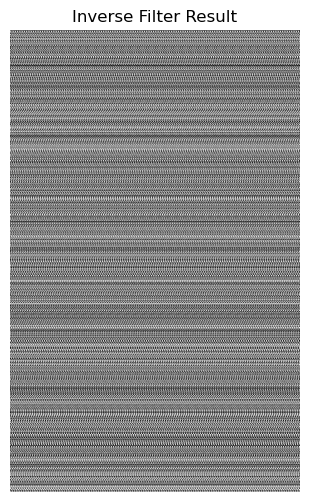

In [17]:
inverse_restored = inverse_filter_restore(degraded_image, blur_kernel)

plt.figure(figsize=(6, 6))
plt.imshow(np.clip(inverse_restored, 0, 1), cmap='gray')
plt.title('Inverse Filter Result')
plt.axis('off')
plt.show()

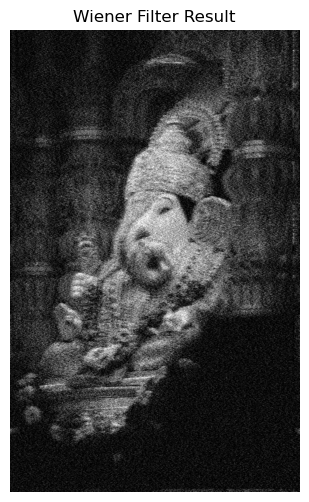

In [19]:
wiener_restored = wiener_filter_restore(degraded_image, blur_kernel, K=0.05)

plt.figure(figsize=(6, 6))
plt.imshow(np.clip(wiener_restored, 0, 1), cmap='gray')
plt.title('Wiener Filter Result')
plt.axis('off')
plt.show()